(1690, 2945, 3)


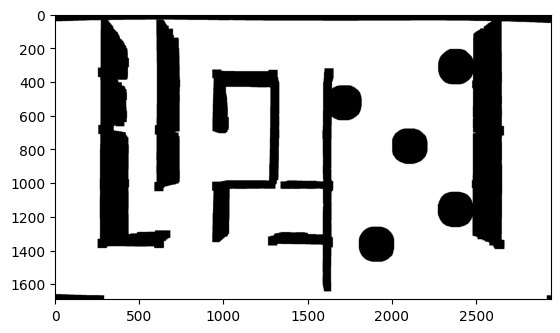

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Open an image
IMAGE_FILE = "continuous_example_1.jpeg"
thresh = 128
maxval = 255

img_maze = cv2.imread(IMAGE_FILE)
img_hsv = cv2.cvtColor(img_maze[260:1950, 480:3425], cv2.COLOR_BGR2HSV)

hsv_mask = cv2.inRange(img_hsv, (4,38,101), (27,255, 255))

_, threshed = cv2.threshold(hsv_mask, thresh, maxval, cv2.THRESH_BINARY)
threshed_3_channel = cv2.cvtColor(threshed, cv2.COLOR_GRAY2BGR)

kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), np.uint8)
threshed_3_channel = cv2.dilate(threshed_3_channel, kernel, iterations = 4)

kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), np.uint8)
threshed_3_channel = cv2.erode(threshed_3_channel, kernel, iterations = 21)

print(threshed_3_channel.shape)
pts1 = np.float32()

# plt.figure(figsize = (9,5))
plt.imshow(threshed_3_channel)
plt.show()

In [72]:


class Node:
    def __init__(self, node_id, x, y):
        self.id = node_id
        self.x = x
        self.y = y
    
    def get_point(self):
        return (self.x,self.y)
    
    def get_ID(self):
        return self.id

class Graph:
    def __init__(self):
        self.nodes = {}
        self.edges = {}

    def add_node(self, node_id, x, y):
        if node_id not in self.nodes:
            self.nodes[node_id] = Node(node_id, x, y)
            self.edges[node_id] = {}
        pass

    def add_edge(self, node_id1, node_id2, weight):
        if node_id1 in self.nodes and node_id2 in self.nodes:
            self.edges[node_id1][node_id2] = weight
            self.edges[node_id2][node_id1] = weight
        pass

    def remove_edge(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            del self.edges[node_id1][node_id2]
            del self.edges[node_id2][node_id1]
        pass
    
    def get_nodes(self):
        return self.nodes
    
    def get_edge_weight(self, node_id1, node_id2):
        if node_id1 in self.edges and node_id2 in self.edges[node_id1]:
            return self.edges[node_id1][node_id2]
        return None 

In [73]:
def path_clear(image, x1, y1, x2, y2):
    height, width = image.shape[:2]
    for t in range(101):
        t /= 100.0
        x = int(x1 * (1 - t) + x2 * t)
        y = int(y1 * (1 - t) + y2 * t)
        x = max(0, min(x, width - 1))  # Clamp x
        y = max(0, min(y, height - 1))  # Clamp y
        if (image[y, x][0] == 0 and image[y, x][1] == 0 and image[y, x][2] == 0) or (image[y, x][0] == 255 and image[y, x][1] == 0 and image[y, x][2] == 0):  # Black or red
            return False
    return True


Total nodes: 378
Node ID: 0, Coordinates: (150, 150)
Node ID: 1, Coordinates: (255, 150)
Node ID: 2, Coordinates: (360, 150)
Node ID: 3, Coordinates: (465, 150)
Node ID: 4, Coordinates: (570, 150)
Node ID: 5, Coordinates: (675, 150)
Node ID: 6, Coordinates: (780, 150)
Node ID: 7, Coordinates: (885, 150)
Node ID: 8, Coordinates: (990, 150)
Node ID: 9, Coordinates: (1095, 150)
Node ID: 10, Coordinates: (1200, 150)
Node ID: 11, Coordinates: (1305, 150)
Node ID: 12, Coordinates: (1410, 150)
Node ID: 13, Coordinates: (1515, 150)
Node ID: 14, Coordinates: (1620, 150)
Node ID: 15, Coordinates: (1725, 150)
Node ID: 16, Coordinates: (1830, 150)
Node ID: 17, Coordinates: (1935, 150)
Node ID: 18, Coordinates: (2040, 150)
Node ID: 19, Coordinates: (2145, 150)
Node ID: 20, Coordinates: (2250, 150)
Node ID: 21, Coordinates: (2355, 150)
Node ID: 22, Coordinates: (2460, 150)
Node ID: 23, Coordinates: (2565, 150)
Node ID: 24, Coordinates: (2670, 150)
Node ID: 25, Coordinates: (2775, 150)
Node ID: 26, C

Edge from 0 to 27, Weight: 1
Edge from 6 to 7, Weight: 1
Edge from 7 to 6, Weight: 1
Edge from 7 to 8, Weight: 1
Edge from 7 to 34, Weight: 1
Edge from 8 to 7, Weight: 1
Edge from 8 to 9, Weight: 1
Edge from 8 to 35, Weight: 1
Edge from 9 to 8, Weight: 1
Edge from 9 to 10, Weight: 1
Edge from 9 to 36, Weight: 1
Edge from 10 to 9, Weight: 1
Edge from 10 to 11, Weight: 1
Edge from 10 to 37, Weight: 1
Edge from 11 to 10, Weight: 1
Edge from 11 to 12, Weight: 1
Edge from 11 to 38, Weight: 1
Edge from 12 to 11, Weight: 1
Edge from 12 to 13, Weight: 1
Edge from 12 to 39, Weight: 1
Edge from 13 to 12, Weight: 1
Edge from 13 to 14, Weight: 1
Edge from 13 to 40, Weight: 1
Edge from 14 to 13, Weight: 1
Edge from 14 to 15, Weight: 1
Edge from 14 to 41, Weight: 1
Edge from 15 to 14, Weight: 1
Edge from 15 to 16, Weight: 1
Edge from 15 to 42, Weight: 1
Edge from 16 to 15, Weight: 1
Edge from 16 to 17, Weight: 1
Edge from 16 to 43, Weight: 1
Edge from 17 to 16, Weight: 1
Edge from 17 to 18, Weight: 

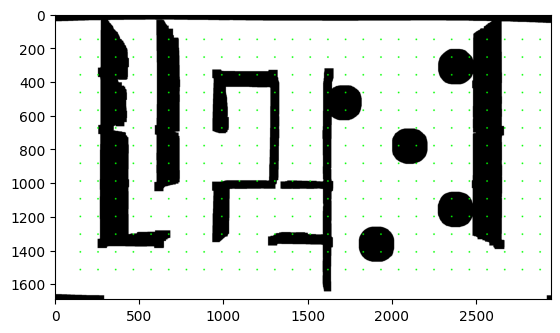

In [74]:
# Cell 4: Modified Graph Generation with 14x27 Grid and Obstacle Avoidance

bfs_image = threshed_3_channel.copy()
bfs_graph = Graph()

node_id = 0
size_of_node_grid = 20

# Initialize the size of the array
img_width = bfs_image.shape[1]
img_height = bfs_image.shape[0]

# Use original grid spacing
grid_spacing_x = 105
grid_spacing_y = 105

# Get nodes
dictionary = bfs_graph.get_nodes()
height = 14  # 14 rows
width = 27   # 27 columns
border = 150

# Generate nodes
for i in range(height):
    for j in range(width):
        x = border + j * grid_spacing_y
        y = border + i * grid_spacing_x
        bfs_graph.add_node(node_id, x, y)
        node_id += 1

print("Total nodes:", node_id)

# Print all nodes and their coordinates
for node_id, node in dictionary.items():
    print(f"Node ID: {node_id}, Coordinates: {node.get_point()}")

# Add horizontal and vertical edges, considering obstacle avoidance
def is_safe_path(img, x1, y1, x2, y2):
    clearance = 90  # Clearance buffer equal to the robot's size
    return path_clear(img, x1, y1, x2, y2) and (
        all(img[y1-clearance:y1+clearance, x1-clearance:x1+clearance].mean(axis=(0, 1)) > 200) and
        all(img[y2-clearance:y2+clearance, x2-clearance:x2+clearance].mean(axis=(0, 1)) > 200)
    )

for i in range(0, node_id - 1, width):
    for j in range(width - 1):
        node_id1 = i + j
        node_id2 = node_id1 + 1
        if node_id2 < node_id:  # Ensure node_id2 is within bounds
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            if is_safe_path(bfs_image, x1, y1, x2, y2):
                bfs_graph.add_edge(node_id1, node_id2, 1)

for i in range(width):
    for j in range(0, node_id - width, width):
        node_id1 = i + j
        node_id2 = node_id1 + width
        if node_id2 < node_id:  # Ensure node_id2 is within bounds
            x1, y1 = dictionary[node_id1].get_point()
            x2, y2 = dictionary[node_id2].get_point()
            if is_safe_path(bfs_image, x1, y1, x2, y2):
                bfs_graph.add_edge(node_id1, node_id2, 1)

# Print all edges
for node_id, edges in bfs_graph.edges.items():
    for neighbor, weight in edges.items():
        print(f"Edge from {node_id} to {neighbor}, Weight: {weight}")

# Display nodes            
for node_id in dictionary:
    x, y = dictionary[node_id].get_point()
    cv2.circle(bfs_image, (x, y), 5, (0, 255, 0), -1)

# Display Resulting Image
plt.imshow(bfs_image)
plt.show()


Start ID: 118, Goal ID: 26
Start Coordinates: (1200, 570), Goal Coordinates: (2880, 150)
Start Node Edges: {117: 1, 145: 1}
Goal Node Edges: {25: 1, 53: 1}


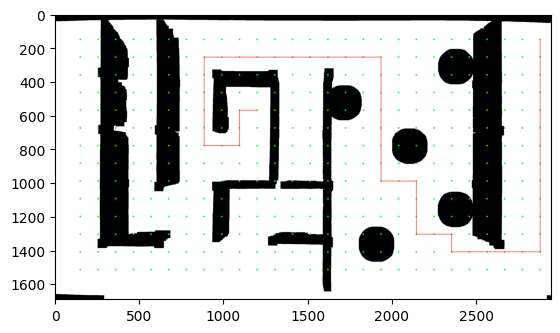

Connection: 118 -> 117
Connection: 117 -> 144
Connection: 144 -> 171
Connection: 171 -> 170
Connection: 170 -> 169
Connection: 169 -> 142
Connection: 142 -> 115
Connection: 115 -> 88
Connection: 88 -> 61
Connection: 61 -> 34
Connection: 34 -> 35
Connection: 35 -> 36
Connection: 36 -> 37
Connection: 37 -> 38
Connection: 38 -> 39
Connection: 39 -> 40
Connection: 40 -> 41
Connection: 41 -> 42
Connection: 42 -> 43
Connection: 43 -> 44
Connection: 44 -> 71
Connection: 71 -> 98
Connection: 98 -> 125
Connection: 125 -> 152
Connection: 152 -> 179
Connection: 179 -> 206
Connection: 206 -> 233
Connection: 233 -> 234
Connection: 234 -> 235
Connection: 235 -> 262
Connection: 262 -> 289
Connection: 289 -> 316
Connection: 316 -> 317
Connection: 317 -> 318
Connection: 318 -> 345
Connection: 345 -> 346
Connection: 346 -> 347
Connection: 347 -> 348
Connection: 348 -> 349
Connection: 349 -> 350
Connection: 350 -> 323
Connection: 323 -> 296
Connection: 296 -> 269
Connection: 269 -> 242
Connection: 242 ->

In [75]:
# Cell 5: Using Directly Specified Node IDs

# Directly specify the start and goal node IDs based on your observation
start_id = 118  # Updated based on your observation
goal_id = 26  # Updated based on your observation

# Ensure node_id is within bounds and check node coordinates
if start_id >= len(dictionary) or goal_id >= len(dictionary):
    print(f"Invalid node IDs. Start ID: {start_id}, Goal ID: {goal_id}")
else:
    print(f"Start ID: {start_id}, Goal ID: {goal_id}")
    print(f"Start Coordinates: {dictionary[start_id].get_point()}, Goal Coordinates: {dictionary[goal_id].get_point()}")

    # Check if start and goal nodes are connected to neighbors
    print(f"Start Node Edges: {bfs_graph.edges.get(start_id, 'No connections')}")
    print(f"Goal Node Edges: {bfs_graph.edges.get(goal_id, 'No connections')}")

    # BFS Pathfinding
    def bfs(graph, start, goal):
        from collections import deque
        queue = deque([start])
        visited = {start: None}
        
        while queue:
            current = queue.popleft()
            
            if current == goal:
                path = []
                while current is not None:
                    path.append(current)
                    current = visited[current]
                return path[::-1]  # Reverse the path
            
            for neighbor in graph.edges[current]:
                if neighbor not in visited:
                    visited[neighbor] = current
                    queue.append(neighbor)
        
        return None

    # Perform BFS
    path = bfs(bfs_graph, start_id, goal_id)

    if path:
        # Draw the path
        for i in range(len(path) - 1):
            node_id1 = path[i]
            node_id2 = path[i + 1]

            # Ensure node_id1 and node_id2 are connected
            if node_id2 in bfs_graph.edges[node_id1]:
                x1, y1 = dictionary[node_id1].get_point()
                x2, y2 = dictionary[node_id2].get_point()
                cv2.line(bfs_image, (x1, y1), (x2, y2), (255, 0, 0), 2)  # Draw path in blue

        plt.imshow(bfs_image)
        plt.show()
    else:
        print("No path found")

    # Check connections along the path
    if path:
        for i in range(len(path) - 1):
            print(f"Connection: {path[i]} -> {path[i+1]}")


In [76]:
# Cell 6: Generate Command String from Path with Corrected Logic

def generate_command_string(path):
    command_string = "f"  # Start with a forward movement, since the robot always moves forward initially
    
    for i in range(1, len(path) - 1):
        prev_node = path[i - 1]
        current_node = path[i]
        next_node = path[i + 1]
        
        prev_diff = current_node - prev_node
        next_diff = next_node - current_node
        
        if prev_diff == 27 and next_diff == 1:
            command_string += "l"  # Turn left to move right
        elif prev_diff == -27 and next_diff == -1:
            command_string += "l"  # Turn left to move left
        elif prev_diff == 1 and next_diff == -27:
            command_string += "l"  # Turn left to move up
        elif prev_diff == -1 and next_diff == 27:
            command_string += "l"  # Turn left to move down
        elif prev_diff == 27 and next_diff == -1:
            command_string += "r"  # Turn right to move left
        elif prev_diff == -27 and next_diff == 1:
            command_string += "r"  # Turn right to move right
        elif prev_diff == 1 and next_diff == 27:
            command_string += "r"  # Turn right to move down
        elif prev_diff == -1 and next_diff == -27:
            command_string += "r"  # Turn right to move up
        command_string += "f"  # After turning, move forward
        
    return command_string  # Remove the extra forward move at the end

# Generate the command string based on the path from cell 5
if path:
    command_string = generate_command_string(path)
    print("Generated Command String:")
    print(command_string)
else:
    print("No path found, unable to generate command string.")


Generated Command String:
flffrffrfffffrffffffffffrffffffflffrffflffrflffffflffffffffffff


In [77]:
def generate_command_string(path):
    command_string = ""  # Initialize the command string

    if len(path) > 1:
        # Determine the first movement type based on the first difference
        first_diff = path[1] - path[0]
        if first_diff in [1, -1]:
            command_string += "f"  # Horizontal movement (row)
        elif first_diff in [27, -27]:
            command_string += "c"  # Vertical movement (column)

    for i in range(1, len(path) - 1):
        prev_node = path[i - 1]
        current_node = path[i]
        next_node = path[i + 1]
        
        prev_diff = current_node - prev_node
        next_diff = next_node - current_node
        
        # Determine the turn direction
        if prev_diff == 27 and next_diff == 1:
            command_string += "l"  # Turn left to move right
        elif prev_diff == -27 and next_diff == -1:
            command_string += "l"  # Turn left to move left
        elif prev_diff == 1 and next_diff == -27:
            command_string += "l"  # Turn left to move up
        elif prev_diff == -1 and next_diff == 27:
            command_string += "l"  # Turn left to move down
        elif prev_diff == 27 and next_diff == -1:
            command_string += "r"  # Turn right to move left
        elif prev_diff == -27 and next_diff == 1:
            command_string += "r"  # Turn right to move right
        elif prev_diff == 1 and next_diff == 27:
            command_string += "r"  # Turn right to move down
        elif prev_diff == -1 and next_diff == -27:
            command_string += "r"  # Turn right to move up

        # Add the correct movement type
        if next_diff in [1, -1]:
            command_string += "f"  # Horizontal movement (row)
        elif next_diff in [27, -27]:
            command_string += "c"  # Vertical movement (column)
        
    return command_string

# Generate the command string based on the path from cell 5
if path:
    command_string = generate_command_string(path)
    print("Generated Command String:")
    print(command_string)
else:
    print("No path found, unable to generate command string.")


Generated Command String:
flccrffrcccccrffffffffffrccccccclffrccclffrclffffflcccccccccccc
